# Assignment 4 — Digital Image Processing

**Folder layout**
```bash
src/
  main.ipynb  #code, results, and written answers
utils/       #given data
outputs/     #obtained outputs
  q1/         
  q2/
  q3/ 
  q4/
  q5/
  q6/
  q7/
  #q8 outputs are displayed in this notebook itself.
```

In [1]:
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import convolve
from scipy.ndimage import maximum_filter
import time
from sklearn.cluster import AgglomerativeClustering
import json
from collections import Counter

#to save all figures for better visualization
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Question 1


#### Steps

1. ***Load Image***:   
    the low-resolution input is read in color for further enhancement.
2. ***Gaussian Low-Pass Filtering***:   
    a 2D Gaussian kernel (13×13) is convolved with the image to extract only low-frequency content, removing noise and smoothing blocky
3. ***High-Boost Filtering (Unsharp Mask)***:   
    To enhance edges after smoothing, high-boost filtering was applied using the formula:

$$
\text{Output}(x,y) = A \cdot f(x,y) \;-\; (A-1)\cdot f_{\text{low}}(x,y)
$$
with a boost boost factor A=11.     
This strongly enhances edges and restores sharpness lost in the low-pass step.

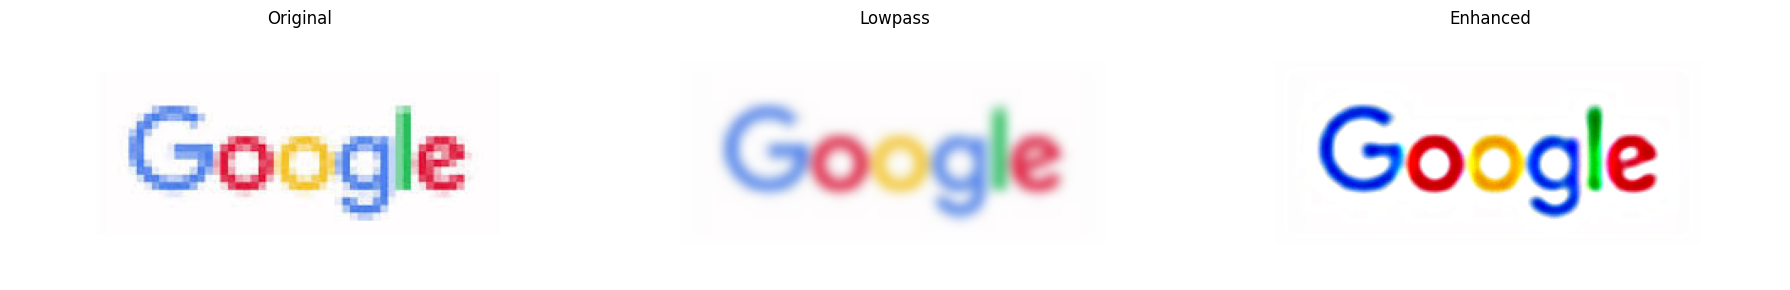

all outputs saved in: c:\Users\reddy\Downloads\assign4\outputs\q1


In [2]:
class ImageEnhancer:
    #handles frequency domain image enhancement operations
    def __init__(self, source_path):
        self.original = cv2.imread(source_path)
        if self.original is None:
            raise FileNotFoundError(f"Unable to load image from {source_path}")
    
    def _build_gaussian_matrix(self, radius, spread):
        #generate 2d gaussian distribution for convolution
        dimension = 2 * radius + 1
        coords = np.arange(-radius, radius + 1)
        grid_x, grid_y = np.meshgrid(coords, coords)
        
        # Gaussian formula: G(x,y) = (1/2πσ²) * e^(-(x²+y²)/2σ²)
        gaussian = np.exp(-(grid_x**2 + grid_y**2) / (2 * spread**2))
        return gaussian / gaussian.sum()  # Normalize
    
    #apply low pass filtering via gaussian blur
    def extract_low_frequencies(self, radius, spread):
        matrix = self._build_gaussian_matrix(radius, spread)
        
        if self.original.ndim == 3:
            result = np.zeros_like(self.original, dtype=np.float32)
            for channel_idx in range(self.original.shape[2]):
                result[:, :, channel_idx] = convolve(
                    self.original[:, :, channel_idx].astype(np.float32),
                    matrix
                )
        else:
            result = convolve(self.original.astype(np.float32), matrix)
        
        return np.clip(result, 0, 255).astype(np.uint8)
    
    #nhances edges using unsharp masking technique
    #amplification*Original - (Amplification-1)*Blurred
    def sharpen_via_unsharp_mask(self, blur_radius, blur_spread, amplification):
        blurred_version = self.extract_low_frequencies(blur_radius, blur_spread)
        
        original_float = self.original.astype(np.float32)
        blurred_float = blurred_version.astype(np.float32)
        
        #high-boost formula: A*f(x,y) - (A-1)*f_lowpass(x,y)
        sharpened = amplification * original_float - (amplification - 1) * blurred_float
        
        return np.clip(sharpened, 0, 255).astype(np.uint8)

if __name__ == "__main__":

    OUTPUT_DIR = "../outputs/q1"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    processor = ImageEnhancer('../utils/google.jpeg')
    
    #parameters
    BLUR_RADIUS = 6  # 13x13 kernel
    BLUR_SIGMA = 3.0
    BOOST_FACTOR = 11.0
    
    smoothed_image = processor.extract_low_frequencies(BLUR_RADIUS, BLUR_SIGMA)
    
    #apply sharpening to the already-smoothed image
    enhancer_pass2 = ImageEnhancer.__new__(ImageEnhancer)
    enhancer_pass2.original = smoothed_image
    final_output = enhancer_pass2.sharpen_via_unsharp_mask(
        BLUR_RADIUS, 
        BLUR_SIGMA, 
        BOOST_FACTOR
    )

    cv2.imwrite(os.path.join(OUTPUT_DIR, "0_original.jpg"), processor.original)
    cv2.imwrite(os.path.join(OUTPUT_DIR, "1_lowpass.jpg"), smoothed_image)
    cv2.imwrite(os.path.join(OUTPUT_DIR, "2_highboost.jpg"), final_output)
    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(processor.original, cv2.COLOR_BGR2RGB))
    plt.title("Original"); plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cv2.cvtColor(smoothed_image, cv2.COLOR_BGR2RGB))
    plt.title("Lowpass"); plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB))
    plt.title("Enhanced"); plt.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "comparison.png"), dpi=300)
    plt.show()

    print("all outputs saved in:", os.path.abspath(OUTPUT_DIR))
    

#### Result

The enhanced image shows:  
- sharper boundaries around the logo letters
- more vivid colors after sharpening
- improved edge contrast without amplifying noise
- smoother internal regions thanks to Gaussian pre-processing
- and therefore a better contrast and visibility across the entire image.

#### Observations

- a large high-boost factor (A=11) improves sharpness but can exaggerate noise if the low-pass filter isn’t strong enough
- a larger Gaussian kernel (13×13) was necessary to prevent artifacts when boosting edges
- using a custom Gaussian matrix provides more control than OpenCV’s built-ins
- applying high-boost after strong smoothing gives a more natural look

---

## Question 2

The objective is to identify and count the number of coins in an image using ***morphological image processing*** techniques such as thresholding, erosion, dilation, and contour detection.

#### Implemented Pipeline

- Image Reading and preprocessing
    - the input image is read in BGR format and converted to grayscale to simplify analysis.
    - A Gaussian blur with kernel size `(7×7)` is applied to smooth out high-frequency noise and make thresholding more stable.
- Otsu’s Inverse Thresholding
    - Otsu’s method automatically determines the optimal threshold separating the coins (dark or bright regions) from the background.
    - used inverse thresholding because the coins appear darker on a relatively bright background.
- Morphological Cleanup (Closing and Opening)
    - Closing fills small gaps within coins.
    - Opening removes small noise specks from the background.
- Contour Detection and Filtering
    - After obtaining the clean binary mask, contours are extracted.
    - Only contours with an area greater than a certain threshold (15000 pixels) are considered valid coins.
    - Each detected coin is outlined with a green circle using `cv2.minEnclosingCircle()`.

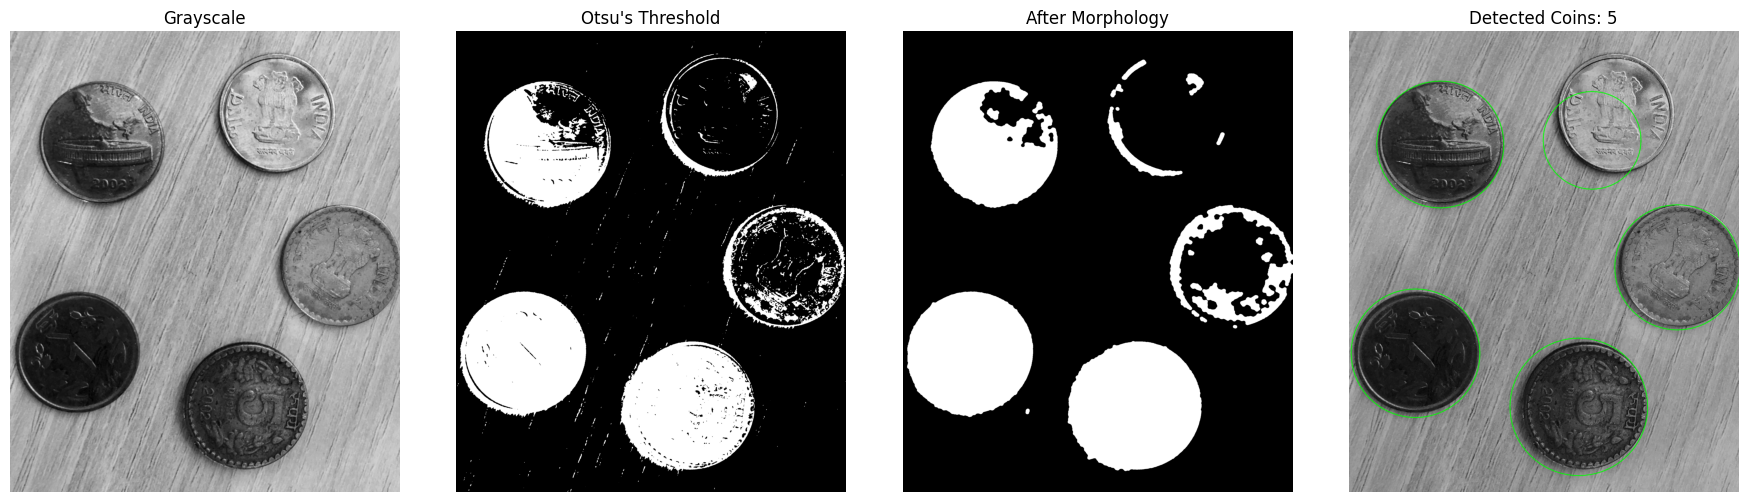

Detected coins: 5
outputs saved


In [3]:
def count_coins(image_path, output_dir="../outputs/q2", display=True):

    img = cv2.imread(image_path)
    os.makedirs(output_dir, exist_ok=True)

    #preprocessing
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_img = cv2.GaussianBlur(gray_img, (7, 7), 0)
    cv2.imwrite(os.path.join(output_dir, "1_grayscale.jpg"), gray_img)

    #otsu inverse threshold
    _, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cv2.imwrite(os.path.join(output_dir, "2_otsu_binary.jpg"), binary)

    #morphology operations (closing then opening)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    closed_img = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    morphed_img = cv2.morphologyEx(closed_img, cv2.MORPH_OPEN, kernel)
    cv2.imwrite(os.path.join(output_dir, "3_morph_cleaned.jpg"), morphed_img)

    #contour filtering
    contours, _ = cv2.findContours(morphed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    area_thresh = 15000
    coins = [c for c in contours if cv2.contourArea(c) > area_thresh]

    output = img.copy()
    for c in coins:
        (x, y), r = cv2.minEnclosingCircle(c)
        cv2.circle(output, (int(x), int(y)), int(r), (0, 255, 0), 4)
    
    cv2.imwrite(os.path.join(output_dir, "4_final_detected.jpg"), output)

    if display:
        plt.figure(figsize=(18, 5))
        for i, (title, im, cmap) in enumerate([
            ("Grayscale", gray_img, 'gray'),
            ("Otsu's Threshold", binary, 'gray'),
            ("After Morphology", morphed_img, 'gray'),
            (f"Detected Coins: {len(coins)}", cv2.cvtColor(output, cv2.COLOR_BGR2RGB), None)
        ]):
            plt.subplot(1, 4, i+1)
            plt.title(title)
            plt.axis('off')
            plt.imshow(im, cmap=cmap)
        plt.tight_layout()
        plt.show()

        print(f"Detected coins: {len(coins)}")
        print(f"outputs saved")

    return len(coins), output

num, _ = count_coins('../utils/coin.jpg')


#### Result

- Detected Coins: `len(coins)` = **5**

#### Observations

- The combination of ***Gaussian blurring + Otsu thresholding*** worked well for unevenly lit metallic surfaces.
- Proper kernel sizing in morphology (around 15–25 px for this image size) played a main role in this process.
- varying area threshold ensured smaller reflections or artifacts aren’t mistaken for coins.

---

## Question 3

The objective is to perform skeletonization on the given `human.png` image and extract a skeletal structure representing the human silhouette.

#### Pipeline Used

- Image Reading (Alpha-Aware):
    - The provided image (`human.png`) contains an alpha channel defining the human silhouette’s transparency.
    - Instead of using only RGB channels, the image was read using cv2.IMREAD_UNCHANGED to preserve the alpha channel.
- Binary Mask Extraction:
    - The alpha channel was used to generate a binary mask, where:
        - Foreground (human body): 255 (white)
        - Background: 0 (black)
    - If no alpha channel existed, Otsu’s thresholding would have been used as a fallback.
- Morphological Skeletonization:
    - The skeleton was generated using an iterative morphological approach:
        - Erode the binary image repeatedly with a cross-shaped kernel.
        - After each erosion, apply morphological opening to remove small noise.
        - Subtract the opened image from the eroded image to extract the contour layer.
        - Accumulate all extracted contour layers into the final skeleton mask.
        - Repeat until the image is fully eroded (no white pixels remain).

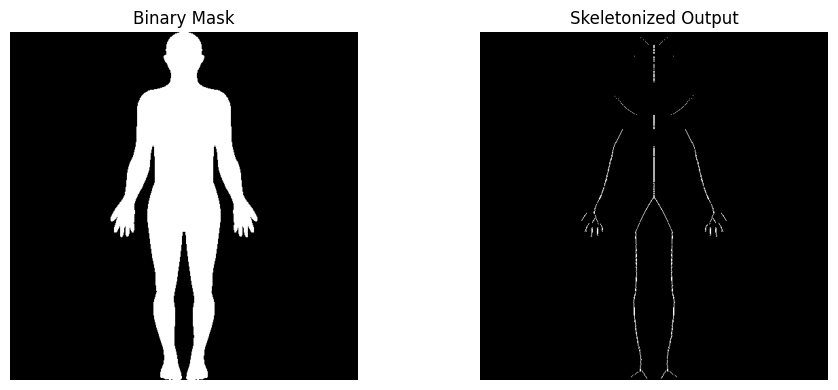

outputs saved to: c:\Users\reddy\Downloads\assign4\outputs\q3


In [4]:
def skeletonize_human(image_path, output_dir="../outputs/q3", display=True):
    os.makedirs(output_dir, exist_ok=True)

    #load image with alphal
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    #extract binary mask
    if img.shape[2] == 4:  #has alpha channel
        alpha = img[:, :, 3]
        binary = np.where(alpha > 0, 255, 0).astype(np.uint8)
    else:  #if no alpha
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cv2.imwrite(os.path.join(output_dir, "1_binary_mask.jpg"), binary)

    #morphological skeletonization
    A = (binary > 0).astype(np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    skeleton = np.zeros_like(A)
    iteration = 0

    while True:
        eroded = cv2.erode(A, element)
        opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, element)
        temp = cv2.subtract(eroded, opened)
        skeleton = cv2.bitwise_or(skeleton, temp)
        A = eroded.copy()
        iteration += 1

        if cv2.countNonZero(A) == 0:
            break

    skeleton_img = (skeleton * 255).astype(np.uint8)
    cv2.imwrite(os.path.join(output_dir, "2_skeletonized.jpg"), skeleton_img)

    if display:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title("Binary Mask")
        plt.axis('off')
        plt.imshow(binary, cmap='gray')
        plt.subplot(1, 2, 2)
        plt.title("Skeletonized Output")
        plt.axis('off')
        plt.imshow(skeleton_img, cmap='gray')
        plt.tight_layout()
        plt.show()

    print(f"outputs saved to: {os.path.abspath(output_dir)}")

    return skeleton_img

# Run it
_ = skeletonize_human("../utils/human.png")


#### Output

- ***Binary Mask***: White silhouette on a black background.
- ***Skeletonized Output***: A thin, connected representation of the human figure’s structure.

#### Result

- The resulting skeleton captures the central structure of the human silhouette; including the torso, limbs, and head outline.

---

## Question 4

#### Pipeline

- Binary Thresholding
    - the fingerprint is first converted into a binary image using a fixed global threshold. this separates ridge structures (dark) from the background (light) for easier morphological processing.
- Morphological Opening
    - a 7×7 structuring element is used to remove isolated white specks and small noise left after binarization. this step preserves the ridge flow while clearing background clutter.
- Morphological Closing
    - closing fills tiny gaps inside ridge structures, smooths line continuity, and reconnects broken ridge segments caused by thresholding.
- Edge Extraction (Canny)
    - after the fingerprint has been cleaned and refined, Canny edge detection is applied to capture clear ridge boundaries. the threshold pair (40,120) balances strong edges and finer ridge-line curves.



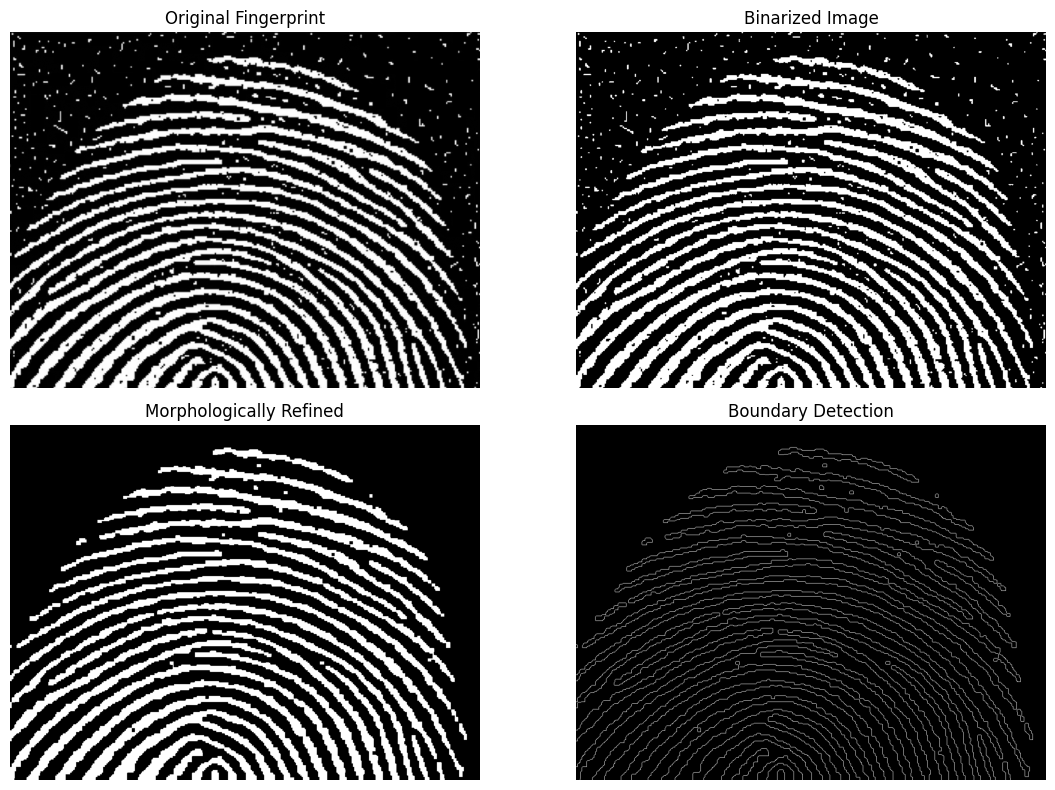

All outputs saved to: c:\Users\reddy\Downloads\assign4\outputs\q4


In [5]:
#configuration parameters
CONFIG = {
    'image_path': '../utils/fingerprint.png',
    'threshold_value': 120,
    'threshold_max': 255,
    'morph_kernel_dims': (7, 7),
    'canny_low': 40,
    'canny_high': 120,
    'display_rows': 2,
    'display_cols': 2,
    'figure_width': 12,
    'figure_height': 8
}

class FingerprintAnalyzer:
    def __init__(self, config):
        self.cfg = config
        self.source_image = None
        self.processing_results = {}
    
    #read grayscale fingerprint image from disk
    def load_source(self):
        self.source_image = cv2.imread(
            self.cfg['image_path'], 
            cv2.IMREAD_GRAYSCALE
        )
        self.processing_results['raw'] = self.source_image
        return self.source_image is not None
    
    #convert to binary using threshold
    def binarize(self):
        _, binarized = cv2.threshold(
            self.source_image,
            self.cfg['threshold_value'],
            self.cfg['threshold_max'],
            cv2.THRESH_BINARY
        )
        self.processing_results['binary'] = binarized
        return binarized
    
    #clean image using opening and closing operation
    def apply_morphological_operations(self, input_img):
        struct_element = np.ones(
            self.cfg['morph_kernel_dims'], 
            dtype=np.uint8
        )
        
        #remove noise
        opened = cv2.morphologyEx(
            input_img, 
            cv2.MORPH_OPEN, 
            struct_element
        )
        
        #fill gaps
        closed = cv2.morphologyEx(
            opened, 
            cv2.MORPH_CLOSE, 
            struct_element
        )
        
        self.processing_results['refined'] = closed
        return closed
    
    #detect edges using Canny algorithm
    def extract_boundaries(self, preprocessed_img):
        boundary_map = cv2.Canny(
            preprocessed_img,
            self.cfg['canny_low'],
            self.cfg['canny_high']
        )
        self.processing_results['boundaries'] = boundary_map
        return boundary_map
    
    def execute_pipeline(self):
        if not self.load_source():
            raise FileNotFoundError("Cannot load fingerprint image")
        
        bin_img = self.binarize()
        refined_img = self.apply_morphological_operations(bin_img)
        self.extract_boundaries(refined_img)
        
        return self.processing_results

if __name__ == "__main__":
    analyzer = FingerprintAnalyzer(CONFIG)
    results = analyzer.execute_pipeline()
    
    OUTPUT_DIR = "../outputs/q4"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    plt.figure(figsize=(CONFIG['figure_width'], CONFIG['figure_height']))

    stages = ["raw", "binary", "refined", "boundaries"]
    titles = [
        "Original Fingerprint",
        "Binarized Image",
        "Morphologically Refined",
        "Boundary Detection"
    ]

    for i, (stage, title) in enumerate(zip(stages, titles), 1):
        plt.subplot(CONFIG['display_rows'], CONFIG['display_cols'], i)
        plt.imshow(results[stage], cmap='gray')
        plt.title(title)
        plt.axis("off")

        cv2.imwrite(
            os.path.join(OUTPUT_DIR, f"{i}_{stage}.png"),
            results[stage]
        )

    plt.tight_layout()

    comparison_path = os.path.join(OUTPUT_DIR, "fingerprint_pipeline.png")
    plt.savefig(comparison_path, dpi=300)
    plt.show()

    print(f"All outputs saved to: {os.path.abspath(OUTPUT_DIR)}")

#### Observations

- global thresholding produced a clean separation between ridges and background for this particular image.
- the 7×7 morphological operations were effective in suppressing noise while still retaining the ridge flow patterns.
- closing significantly improved ridge continuity, especially in areas where lines were thin or had minor breaks.
- the final Canny output captured clean ridge boundaries with reduced false edges and minimal background interference.

---

## Question 5


The objective is to segment given image using three different thresholding methods: binary thresholding, adaptive thresholding, and Otsu’s thresholding. All methods are to be implemented from scratch.

#### Pipeline

- Binary Thresholding
    - A global threshold value of 127 was selected
    - Each pixel was classified as:
        - 255 if intensity ≥ threshold
        - 0 otherwise
    - This method might work well for images with uniform lighting but struggles with complex or uneven illumination.
- Adaptive Thresholding
    - The image was divided into small local regions using an 11×11 Gaussian-weighted window.
    - For each pixel, the local threshold was computed as: local_mean − C, with C = 2.
    - This allows the threshold to vary based on local brightness, making it suitable for textured or unevenly lit images like the provided one.
- Otsu’s Thresholding
    - The histogram of the image was computed.
    - For every possible threshold from 0–255, between-class variance was calculated.
    - The threshold with the maximum variance was selected as the optimal threshold (Otsu’s threshold).
    - This method finds the best global threshold automatically, assuming a bimodal intensity distribution.

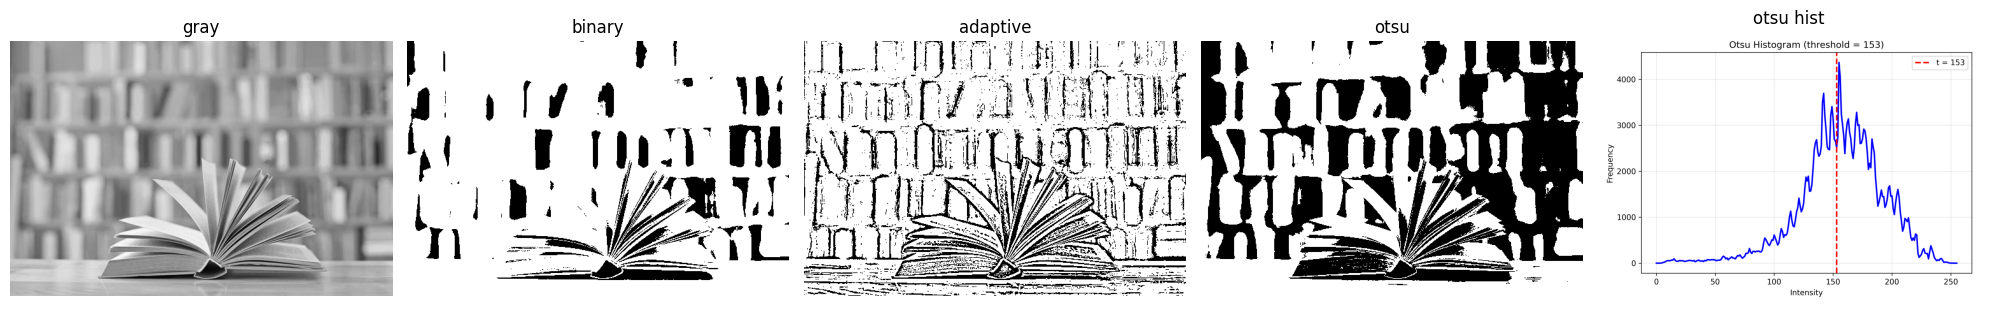

outputs saved to: c:\Users\reddy\Downloads\assign4\outputs\q5
histogram saved as: ../outputs/q5\otsu_histogram.png


In [6]:
def threshold_methods(image_path, output_dir="../outputs/q5", display=True):
    os.makedirs(output_dir, exist_ok=True)

    #read image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    cv2.imwrite(os.path.join(output_dir, "0_gray.jpg"), img)

    #binary thresholding
    t = 127
    binary = np.where(img >= t, 255, 0).astype(np.uint8)
    cv2.imwrite(os.path.join(output_dir, "1_binary.jpg"), binary)

    #adaptive thresholding
    k = 11
    c = 2
    x = cv2.getGaussianKernel(k, 0)
    gaussian = x @ x.T

    padded = cv2.copyMakeBorder(img, k//2, k//2, k//2, k//2, cv2.BORDER_REFLECT)
    adaptive = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+k, j:j+k]
            local_mean = np.sum(region * gaussian) / np.sum(gaussian)
            adaptive[i, j] = 255 if img[i, j] > (local_mean - c) else 0

    adaptive = adaptive.astype(np.uint8)
    cv2.imwrite(os.path.join(output_dir, "2_adaptive.jpg"), adaptive)

    #otsu thresholding
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    total = img.size

    sum_total = np.sum(np.arange(256) * hist)
    sum_b = 0
    w_b = 0
    max_var = 0
    otsu_t = 0

    for t in range(256):
        w_b += hist[t]
        if w_b == 0:
            continue
        w_f = total - w_b
        if w_f == 0:
            break

        sum_b += t * hist[t]
        m_b = sum_b / w_b
        m_f = (sum_total - sum_b) / w_f

        var_between = w_b * w_f * (m_b - m_f) ** 2
        if var_between > max_var:
            max_var = var_between
            otsu_t = t

    otsu = np.where(img >= otsu_t, 255, 0).astype(np.uint8)
    cv2.imwrite(os.path.join(output_dir, "3_otsu.jpg"), otsu)

    plt.figure(figsize=(7,5))
    plt.title(f"Otsu Histogram (threshold = {otsu_t})", fontsize=12)
    plt.plot(hist, color='blue', linewidth=2)
    plt.axvline(x=otsu_t, color='red', linestyle='--', linewidth=2, label=f"t = {otsu_t}")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    hist_path = os.path.join(output_dir, "otsu_histogram.png")
    plt.savefig(hist_path, dpi=300)
    plt.close()

    if display:
        plt.figure(figsize=(20, 6))
        titles = ["gray", "binary", "adaptive", "otsu"]
        images = [img, binary, adaptive, otsu]

        for i in range(4):
            plt.subplot(1, 5, i+1)
            plt.title(titles[i])
            plt.axis('off')
            plt.imshow(images[i], cmap='gray')

        # show histogram separately and bigger
        hist_img = plt.imread(hist_path)
        plt.subplot(1, 5, 5)
        plt.title("otsu hist")
        plt.axis('off')
        plt.imshow(hist_img)

        plt.tight_layout()
        plt.show()

    print(f"outputs saved to: {os.path.abspath(output_dir)}")
    print(f"histogram saved as: {hist_path}")

    return binary, adaptive, otsu


_ = threshold_methods("../utils/thresholding.png")


#### Observations

- Binary Thresholding:
    - Produced a sharply segmented output but lost detail in areas with uneven illumination. Background books with mid-tones were inconsistently thresholded.
- Adaptive Thresholding:
    - Gave the most locally accurate segmentation. Fine edges, book outlines, and page textures were preserved because the threshold adapts to each region’s brightness.
- Otsu's Thresholding:
    - Automatically selected an optimal global threshold, giving strong separation between dark foreground objects and bright background.
    - Some mid-tone regions were suppressed, which is expected due to the strict global split.

##### Which Thresholding Method Is Best?

There is no single “best” thresholding method , it is subjective and depends on lighting, contrast, and texture in the image.

- *Binary Thresholding:*
  Works only when lighting is uniform. In our case, it failed because the image has uneven illumination and lots of mid-tones.

- *Adaptive Thresholding:* 
  Best for images with textured or uneven lighting. From our results, it captured the most detail and handled the bookshelf background well.

- *Otsu’s Thresholding:*
  Best when the histogram is bimodal. In our results, it gave a strong global separation but lost many mid-tone details.

For given image, ***Adaptive thresholding performed the best overall*** because the lighting varies across the scene, while Otsu performed well but was more aggressive, and Binary struggled the most.


---

## Question 6


#### Pipeline

* ***Grayscale Conversion***
  The input image is first converted to a single-channel grayscale representation so that edge gradients and orientation calculations operate purely on intensity values.

* ***Gradient Computation (Sobel)***
  Horizontal and vertical derivatives are obtained using Sobel filters:

  $$
  I_x = \frac{\partial I}{\partial x}, \qquad
  I_y = \frac{\partial I}{\partial y}
  $$

  These gradients provide **edge orientation**, which is essential for direction-based circle voting.

* ***Edge Extraction (Canny)***
  Canny edge detection is applied with a low/high threshold pair:

  * highlights strong edge pixels
  * filters out noise and weak gradients
    Only the coordinates of true edges contribute to the voting process.

* ***Orientation-Based Voting (Gradient Hough)***
  Instead of using OpenCV’s HoughCircles, the algorithm performs **custom voting**:

  For each detected edge pixel:

  * angle $\theta = \arctan2(I_y, I_x)$ is computed
  * two potential circle-center positions are voted:

    * forward direction:
      $$
      (x - r\cos\theta,; y - r\sin\theta)
      $$
    * backward direction:
      $$
      (x + r\cos\theta,; y + r\sin\theta)
      $$

  This is repeated for each radius in the range $[r_{\min}, r_{\max}]$ to accumulate votes in a 3D accumulator.

* ***Radius Selection per Pixel***
  For each pixel, the algorithm selects:
  $$
  \text{best radius} = \arg\max_r;\text{votes}(r,x,y)
  $$
  and keeps the corresponding vote strength.

* ***Local Maxima Suppression***
  A custom neighborhood suppression is applied using a maximum filter:

  * eliminates nearby peaks
  * ensures that only **one strong peak per actual circle** survives
  * removes clusters of detections caused by thick or noisy edges

* ***Confidence Thresholding***
  A global threshold is applied:

  $$
  \text{votes}(x,y) \ge \alpha \cdot \max(\text{votes})
  $$

  where $\alpha$ = `vote_ratio` (e.g., 0.5).
  Only high-confidence circle centers are kept.

* ***Duplicate Removal (NMS Overlap Filtering)***
  A custom filtering stage removes overlapping detections:

  * centers closer than `dist_thresh` are considered duplicates
  * circles with similar radii are also merged
  * only the strongest candidate is preserved


Detected circles:
1: (702,93), r=70
2: (497,309), r=67
3: (224,98), r=74
4: (213,298), r=72
5: (536,96), r=74
6: (75,103), r=67
7: (358,303), r=70
8: (645,308), r=71
9: (388,93), r=67
10: (67,305), r=73


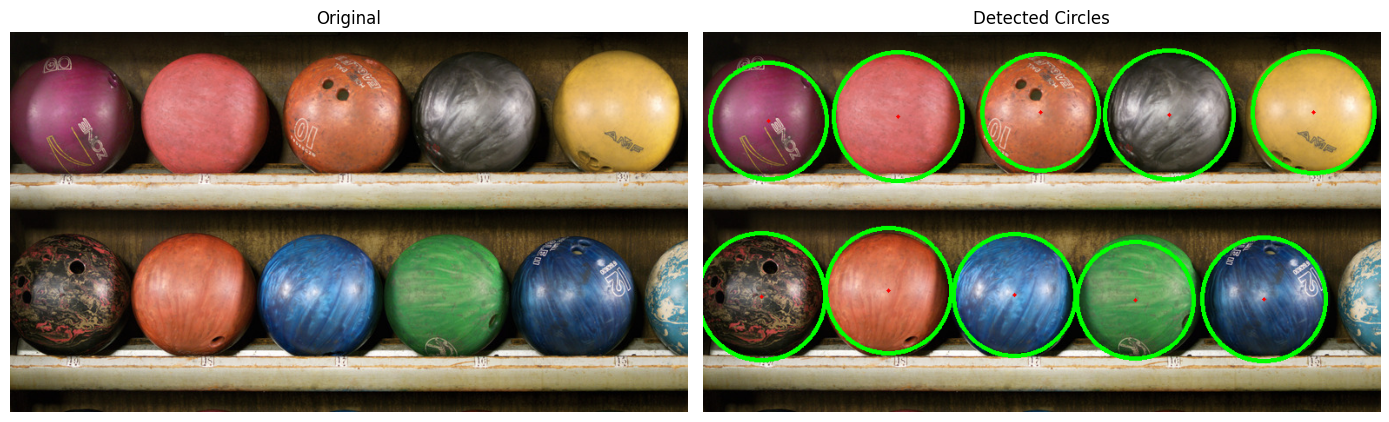

[(702, 93, 70),
 (497, 309, 67),
 (224, 98, 74),
 (213, 298, 72),
 (536, 96, 74),
 (75, 103, 67),
 (358, 303, 70),
 (645, 308, 71),
 (388, 93, 67),
 (67, 305, 73)]

In [7]:
#helper function to remove overlapping duplicates
def filter_overlaps(circle_list, dist_thresh=10, rad_thresh=3):
    if len(circle_list) == 0:
        return []
    ordered = sorted(circle_list, key=lambda x: x[3], reverse=True)
    final = []

    for cx, cy, r, score in ordered:
        ok = True
        for px, py, pr, _ in final:
            if np.hypot(cx - px, cy - py) < dist_thresh and abs(r - pr) <= rad_thresh:
                ok = False
                break
        if ok:
            final.append((cx, cy, r, score))

    return final

#core detector: gradient-based circle votes
def circle_localizer(gray_img,
                     r_min, r_max,
                     suppress_dist,
                     high_canny,
                     vote_ratio,
                     r_step=1):

    low_canny = high_canny // 2

    #gradients - edge orientation
    gx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, 3)
    gy = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, 3)
    ang = np.arctan2(gy, gx)

    #edges
    edges = cv2.Canny(gray_img, low_canny, high_canny)
    ys, xs = np.where(edges > 0)
    ori = ang[ys, xs]

    H, W = gray_img.shape
    radii = np.arange(r_min, r_max, r_step)
    accu = np.zeros((len(radii), H, W), np.uint32)

    t0 = time.time()

    #vote for each radius
    for ridx, r in enumerate(radii):

        #forward votes
        xp = (xs - r * np.cos(ori)).astype(int)
        yp = (ys - r * np.sin(ori)).astype(int)
        mask1 = (xp >= 0) & (xp < W) & (yp >= 0) & (yp < H)
        np.add.at(accu[ridx], (yp[mask1], xp[mask1]), 1)

        #backward votes
        xn = (xs + r * np.cos(ori)).astype(int)
        yn = (ys + r * np.sin(ori)).astype(int)
        mask2 = (xn >= 0) & (xn < W) & (yn >= 0) & (yn < H)
        np.add.at(accu[ridx], (yn[mask2], xn[mask2]), 1)

    #find best radius per pixel
    best_r_idx = np.argmax(accu, axis=0)
    best_votes = np.max(accu, axis=0)

    #local max suppression
    k = max(1, (suppress_dist // 2) * 2 + 1)
    local_max = maximum_filter(best_votes, footprint=np.ones((k, k)))
    peak_mask = (best_votes == local_max)

    #threshold by confidence
    vote_cut = best_votes.max() * vote_ratio
    strong = np.where((peak_mask) & (best_votes >= vote_cut))

    #collect proposals
    props = []
    for y, x in zip(strong[0], strong[1]):
        rid = best_r_idx[y, x]
        props.append((int(x), int(y), int(radii[rid]), int(best_votes[y, x])))

    #remove duplicates
    filtered = filter_overlaps(props,
                               dist_thresh=max(6, suppress_dist // 30),
                               rad_thresh=max(1, r_step * 2))

    #return x, y, r
    return [(a, b, c) for (a, b, c, _) in filtered]

def run_circle_detection(src_path):

    #load + prep
    raw = cv2.imread(src_path)
    rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
    g = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    g = cv2.GaussianBlur(g, (5, 5), 1)

    circles = circle_localizer(
        g,
        r_min=67,
        r_max=75,
        suppress_dist=277,
        high_canny=5,
        vote_ratio=0.5
    )

    print("Detected circles:")
    for i, (cx, cy, r) in enumerate(circles, 1):
        print(f"{i}: ({cx},{cy}), r={r}")

    #draw
    out = rgb.copy()
    for cx, cy, r in circles:
        cv2.circle(out, (cx, cy), r, (0, 255, 0), 3)
        cv2.circle(out, (cx, cy), 2, (255, 0, 0), -1)

    SAVE = "../outputs/q6"
    os.makedirs(SAVE, exist_ok=True)

    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(out)
    plt.title("Detected Circles")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE, "circle_detection_result.png"), dpi=300)
    plt.show()

    return circles

run_circle_detection("../utils/hough.jpg")



#### Results

* The custom algorithm successfully detects circular objects.
* Gradient-orientation voting ensures circle centers are localized even when edges are incomplete.
* Local maxima suppression + overlap filtering prevents multiple detections of the same circle and produces clean, isolated results.
* Output images clearly show accurate circle boundaries and center.

---

## Question 7


#### Pipeline

- ***Grayscale Conversion***
  - the chessboard image is first converted to grayscale so that gradient-based operations work on intensity values only.
- ***Sobel Gradient Computation***
  - horizontal and vertical intensity derivatives are computed manually:   
    $I_x = \frac{\partial I}{\partial x}, \qquad I_y = \frac{\partial I}{\partial y}$     
    these gradients highlight sharp intensity transitions, which typically occur at corners.
- ***Structure Tensor Construction***
  - for each pixel, the second-moment matrix (structure tensor) is computed using smoothed gradient products:

    $$
    M = 
    \begin{bmatrix}
    S(I_x^2) & S(I_x I_y) \\
    S(I_x I_y) & S(I_y^2)
    \end{bmatrix}
    $$     
    Here,    
    - $S(\cdot)$ represents Gaussian smoothing,    
    - which stabilizes the corner response by reducing local noise.

- ***Harris Response Calculation***
  - The Harris corner response is computed using:

    $$
    R = \det(M) - k \cdot (\operatorname{trace}(M))^2
    $$   
    Where:    
    - $\det(M)$ measures overall variation  
    - $\operatorname{trace}(M)$ measures summed directional changes  
    - $k = 0.04$ controls sensitivity  
    - Large $R$ - strong corner,  
    - Small/negative $R$ - edge or flat region.

- ***Normalization & Thresholding***    
  The response map is normalized to the range [0, 1]:   
    - Weak corners (below 1% of max response) are discarded.    
    - This removes noise and edge responses.

- ***Non-Maximum Suppression (NMS)***  
  To avoid detecting multiple corners at the same pixel:   
    - The response map is dilated.   
    - A pixel is kept only if:

    $R(x,y) = \max(R \text{ in its } 3 \times 3 \text{ neighborhood})$    
    This ensures *only one corner survives per region*

- ***Distance-Based Filtering***   
  A minimum spatial distance is enforced between corners:   
    - Corners too close to an already-accepted corner are removed.   
    - This ensures *exactly 98 well-separated chessboard corners*.

- ***Final Corner Selection***  
  From the sorted response list:
    - The top strongest corner points are selected    
    - Until the expected count (98) is reached.


final selected: 98


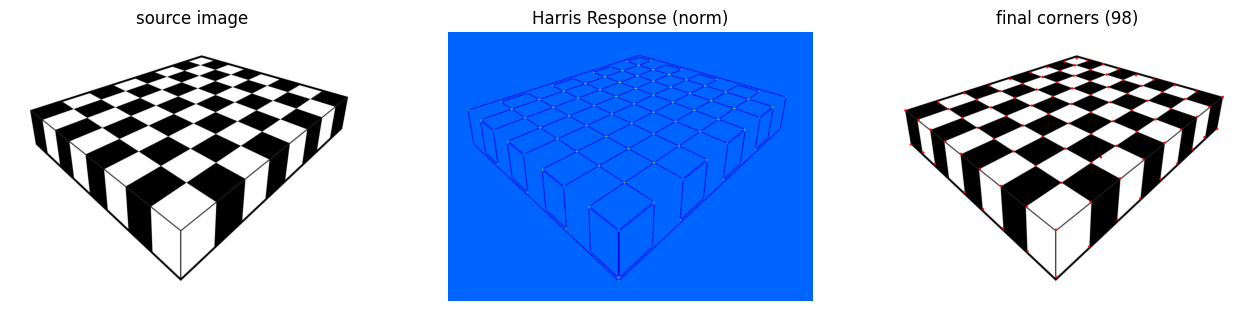

Saved to: c:\Users\reddy\Downloads\assign4\outputs\q7


In [8]:
def detect_harris_no_builtin(
        img_path,
        expected_corners=98,
        k=0.04,
        window=3,
        thresh_rel=0.01,
        min_distance=8
    ):
    
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"cannot load {img_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

    #gradients
    ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    #products
    ixx = ix * ix
    iyy = iy * iy
    ixy = ix * iy

    #smoothing 
    smooth = lambda x: cv2.GaussianBlur(x, (window*2+1, window*2+1), 1.0)
    s_xx = smooth(ixx)
    s_yy = smooth(iyy)
    s_xy = smooth(ixy)

    #harris response
    det = s_xx * s_yy - s_xy * s_xy
    trace = s_xx + s_yy
    R = det - k * (trace ** 2)

    #normalize
    R_norm = (R - R.min()) / (R.max() - R.min() + 1e-12)

    #threshold
    thresh_val = thresh_rel * R_norm.max()
    mask = R_norm > thresh_val

    #NMS
    dilated = cv2.dilate(R_norm, np.ones((3, 3), np.uint8))
    local_max = (R_norm == dilated) & mask

    ys, xs = np.where(local_max)
    responses = R_norm[ys, xs]

    candidates = sorted(
        list(zip(xs, ys, responses)),
        key=lambda z: z[2],
        reverse=True
    )

    #spatial suppression
    final_pts = []
    taken = np.zeros(gray.shape, dtype=np.uint8)

    for (x, y, score) in candidates:
        if len(final_pts) >= expected_corners:
            break
        y0, y1 = max(0, y-min_distance), min(gray.shape[0], y+min_distance+1)
        x0, x1 = max(0, x-min_distance), min(gray.shape[1], x+min_distance+1)

        if taken[y0:y1, x0:x1].any():
            continue

        final_pts.append((x, y, score))
        taken[y0:y1, x0:x1] = 1

    #fallback if needed
    if len(final_pts) < expected_corners:
        for (x, y, score) in candidates:
            if len(final_pts) >= expected_corners:
                break
            if any(np.hypot(x - fx, y - fy) < 1 for (fx, fy, _) in final_pts):
                continue
            final_pts.append((x, y, score))

    #draw results
    marked = img.copy()
    isolated = np.full_like(img, 255)

    for (x, y, s) in final_pts:
        cv2.circle(marked, (int(x), int(y)), 4, (0, 0, 255), -1)
        cv2.circle(isolated, (int(x), int(y)), 4, (255, 0, 0), -1)

    print("final selected:", len(final_pts))

    OUTPUT_DIR = "../outputs/q7"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 3, 1)
    plt.title("source image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Harris Response (norm)")
    plt.imshow(R_norm, cmap='jet')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"final corners ({len(final_pts)})")
    plt.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    save_path = os.path.join(OUTPUT_DIR, "harris_output.png")
    plt.savefig(save_path, dpi=300)
    plt.show()

    cv2.imwrite(os.path.join(OUTPUT_DIR, "corners_marked.png"), marked)
    cv2.imwrite(os.path.join(OUTPUT_DIR, "corners_isolated.png"), isolated)

    print("Saved to:", os.path.abspath(OUTPUT_DIR))

    return final_pts, marked, isolated, R_norm


final_pts, marked, isolated, R_norm = detect_harris_no_builtin(
    "../utils/harris.jpg",
)

#### Result

- The algorithm *successfully extracts the strongest 98 corner responses*, matching the expected number of chessboard intersections.
- Although the algorithm *limits* the output to 98 corners, this is valid because:
  - The Harris response map produces *many candidate peaks*, including duplicates and noise.
  - *NMS + distance filtering* remove redundant corner points.
  - From the remaining strong, well-spaced candidates, we keep the *top 98*, which correspond to the true chessboard intersections.
- pipeline: gradients, smoothing, structure tensor, response computation, thresholding, NMS, and distance filtering.
- The final visual output clearly shows *sharp, isolated, geometrically aligned* corner points, with no clusters or duplicates.


---

## Question 8


#### Pipeline

* ***Grayscale Conversion***

  * The scanned OMR image is first converted into grayscale so that intensity-based processing (thresholding, smoothing, segmentation) works cleanly on a single-channel image.

* ***Smoothing & Thresholding***

  * A Gaussian blur removes small noise.
  * Otsu’s **binary inverse threshold** converts dark bubbles to white foreground and everything else to black background:
    $$\text{BinaryMask}(x,y) =
    \begin{cases}
    255 & \text{if } I(x,y) \le T_{\text{Otsu}} \
    ,0 & \text{otherwise}
    \end{cases}$$

* ***Morphological Cleaning***

  * A small elliptical structuring element removes tiny artifacts:

    * Cleans dots
    * Improves contour stability
    * Ensures candidate regions correspond mostly to filled bubbles

* ***Contour Extraction***

  * External contours are identified from the binary mask.
  * Each contour’s:

    * **Area**
    * **Aspect ratio**
    * **Roundness**
      are evaluated to filter out only bubble-like shapes.
  * Roundness used:
    $$
    \text{Roundness} = \frac{4\pi A}{P^2}
    $$
    Higher values ⇒ more circular.

* ***Valid Circle Detection***

  * For each accepted contour:

    * Minimum enclosing circle gives center + radius
    * Marked in *green* on the overlay image
  * These form the initial set of valid regions.

* ***Overlap Detection***

  * Contours that were rejected earlier but resemble merged/irregular shapes are tested:

    * Size too large
    * Roundness too low
    * Width–height highly unbalanced
  * Such regions are flagged for splitting.

* ***Watershed-Based Region Splitting***

  * For each suspected merged bubble:

    * A padded local region is extracted
    * Distance transform identifies inner peaks
    * Foreground markers + watershed split the region
  * Each split segment is re-validated using the same circle criteria
  * Valid new circles are added (marked *yellow* on intermediate overlay).

* ***Final Region Assembly***

  * Final detected filled bubbles =
    **initial validated regions** + **successful split regions**
  * A clean overlay (green circles) is drawn over the original scan.

* ***Grouping of Answer Regions***

  * Only circles inside the answer grid zone are selected:
    $$x > 215,\quad y > 450$$
  * Their **x-coordinates** undergo hierarchical clustering to divide them into **5 vertical columns**.

* ***Option Mapping (A–D)***

  * Each column finds 4 unique option positions using cluster separation along x–axis.
  * Each bubble is assigned an option:
    $$\text{Option} = \arg\min_i |x - x_i|$$

* ***Row / Question Indexing***

  * Vertical spacing is estimated by analyzing sorted y-positions.
  * Bubbles are assigned to rows → mapped to question numbers
    $$Q = ( \text{column} \times 30 ) + \text{row} + 1$$

* ***Fill Ratio Evaluation***

  * For questions with multiple detected bubbles:

    * Each contour’s mask is intersected with the threshold mask
    * Fill ratio:
      $$
      \text{FillRatio}=\frac{\text{FilledPixels}}{\text{TotalBubblePixels}}
      $$
    * Highest fill ratio = selected answer.

* ***Score Computation***

  * Answer key (A–D) is parsed and converted to numeric:
    $$A=1,; B=2,; C=3,; D=4$$
  * Marking scheme applied per question:

    * **+4** for correct
    * **−1** for wrong
    * **−0.5** for unanswered

* ***Roll Number Extraction***

  * Fixed grid coordinates for each digit bubble
  * For each column (digit):

    * Compute fill level
    * Digit with **lowest white (highest fill)** is chosen
  * Final roll number assembled as an 8-digit string.


Detected 679 regions; Validated 167
Identified 9 suspects for separation.
Separated region at (43,911,74,11) into 2 parts
Separated region at (43,899,75,9) into 2 parts
Separated region at (43,864,75,11) into 1 parts
Separated region at (43,844,75,6) into 2 parts
Separated region at (43,829,75,11) into 2 parts
Separated region at (44,724,74,21) into 3 parts
Separated region at (44,696,74,22) into 2 parts
Separated region at (230,528,18,39) into 2 parts
Separated region at (480,166,30,28) into 2 parts
Total regions: 169 (initial 167 + added 2)


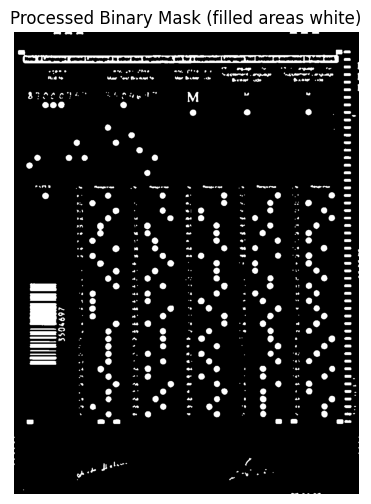

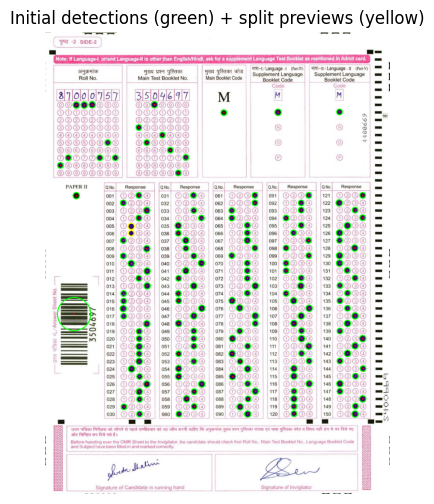

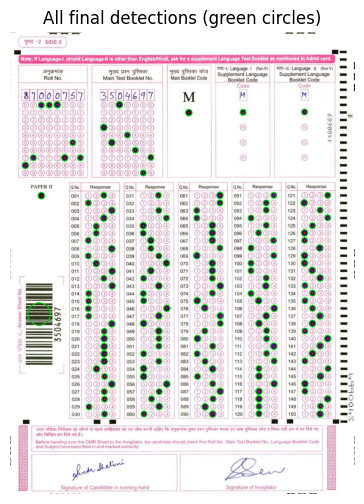

Number of detected centers: 169
[(261, 1058), (560, 1058), (370, 1058), (857, 1058), (688, 1057), (218, 1038), (858, 1036), (688, 1037), (539, 1038), (412, 1037), (561, 1016), (261, 1017), (878, 1016), (688, 1016), (391, 1016), (412, 996), (260, 996), (815, 995), (688, 995), (581, 995), (433, 975), (281, 975), (730, 974), (560, 974), (815, 974), (518, 954), (369, 954), (261, 954), (858, 953), (688, 953), (879, 932), (688, 932), (560, 933), (239, 933), (369, 932), (539, 912), (411, 912), (260, 912), (815, 911), (730, 911), (709, 890), (517, 891), (369, 891), (260, 891), (836, 890), (560, 870), (411, 870), (260, 871), (857, 869), (729, 870), (878, 849), (709, 849), (518, 849), (411, 849), (260, 849), (260, 829), (815, 828), (538, 828), (411, 828), (709, 827), (281, 808), (836, 807), (688, 807), (581, 807), (369, 807), (217, 787), (857, 786), (708, 786), (581, 786), (411, 786), (433, 765), (216, 766), (836, 765), (730, 765), (538, 764), (80, 781), (369, 744), (217, 745), (815, 744), (687,

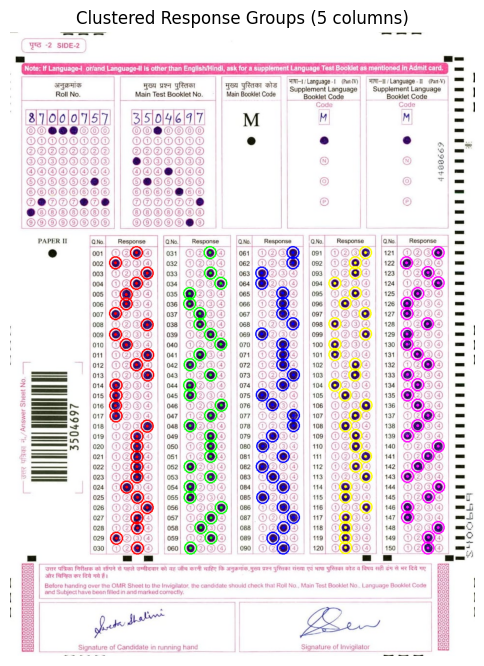

Detected 679 regions; Validated 167
Identified 9 suspects for separation.
Separated region at (43,911,74,11) into 2 parts
Separated region at (43,899,75,9) into 2 parts
Separated region at (43,864,75,11) into 1 parts
Separated region at (43,844,75,6) into 2 parts
Separated region at (43,829,75,11) into 2 parts
Separated region at (44,724,74,21) into 3 parts
Separated region at (44,696,74,22) into 2 parts
Separated region at (230,528,18,39) into 2 parts
Separated region at (480,166,30,28) into 2 parts
Total regions: 169 (initial 167 + added 2)

Response regions count: 149
Vertical spacing estimate: 21
Column group sizes: [30, 29, 30, 30, 30]

Column 1: option positions = [np.int64(216), np.int64(238), np.int64(259), np.int64(281)]

Column 2: option positions = [np.int64(368), np.int64(389), np.int64(410), np.int64(432)]

Column 3: option positions = [np.int64(516), np.int64(538), np.int64(559), np.int64(580)]

Column 4: option positions = [np.int64(666), np.int64(687), np.int64(707), np

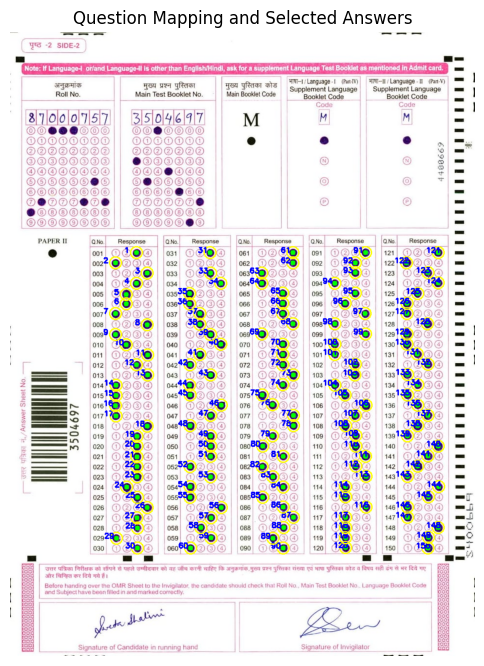


Exam results:
Hits: 145
Misses: 4
Blanks: 1
Final Score: 575.5
Detected 679 regions; Validated 167
Identified 9 suspects for separation.
Separated region at (43,911,74,11) into 2 parts
Separated region at (43,899,75,9) into 2 parts
Separated region at (43,864,75,11) into 1 parts
Separated region at (43,844,75,6) into 2 parts
Separated region at (43,829,75,11) into 2 parts
Separated region at (44,724,74,21) into 3 parts
Separated region at (44,696,74,22) into 2 parts
Separated region at (230,528,18,39) into 2 parts
Separated region at (480,166,30,28) into 2 parts
Total regions: 169 (initial 167 + added 2)
Student ID: 87000757


In [9]:
def visualize_image(image_data, label_text="", color_map='gray', dimensions=(6, 6)):
    plt.figure(figsize=dimensions)
    if image_data is None:
        return
    if len(image_data.shape) == 3:
        plt.imshow(cv2.cvtColor(image_data, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image_data, cmap=color_map)
    plt.title(label_text)
    plt.axis('off')
    plt.show()

#primary function for identifying circular regions in the scan
#detects potential filled circles using contour analysis
#outputs processed binary mask, all detected contours, validated ones, and marked image.
def identify_circular_regions(scan_image, enable_logging=False):
    working_copy = scan_image.copy()
    grayscale_version = cv2.cvtColor(working_copy, cv2.COLOR_BGR2GRAY)
    
    #apply smoothing and adaptive thresholding
    smoothed = cv2.GaussianBlur(grayscale_version, (7, 7), 0)
    _, inverted_threshold = cv2.threshold(smoothed, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    #morphological operation to clean up small artifacts
    structuring_element = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned_mask = cv2.morphologyEx(inverted_threshold, cv2.MORPH_OPEN, structuring_element, iterations=1)
    
    #extract external boundaries
    all_boundaries, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    validated_regions = []
    marked_overlay = working_copy.copy()
    
    for boundary in all_boundaries:
        region_size = cv2.contourArea(boundary)
        if region_size < 80 or region_size > 5000:
            continue
        
        left, top, width, height = cv2.boundingRect(boundary)
        ratio = width / height if height > 0 else 1.0
        if ratio < 0.75 or ratio > 1.25:
            continue
        
        boundary_length = cv2.arcLength(boundary, True)
        if boundary_length == 0:
            continue
        roundness = 4 * np.pi * region_size / (boundary_length ** 2)
        if roundness <= 0.65:
            continue
        
        #valid circle detected
        (center_x, center_y), circle_radius = cv2.minEnclosingCircle(boundary)
        cv2.circle(marked_overlay, (int(center_x), int(center_y)), int(circle_radius), (0, 255, 0), 2)
        cv2.circle(marked_overlay, (int(center_x), int(center_y)), 2, (0, 0, 255), -1)
        validated_regions.append({
            'boundary': boundary,
            'center': (int(center_x), int(center_y)),
            'bounds': (left, top, width, height),
            'size': region_size
        })
    
    if enable_logging:
        print(f"Detected {len(all_boundaries)} regions; Validated {len(validated_regions)}")
    
    return cleaned_mask, all_boundaries, validated_regions, marked_overlay

#function to separate overlapping regions using localized segmentation
#applies watershed segmentation in a local area to divide potentially merged circles.
#returns list of separated boundaries.
def separate_overlapping_regions(binary_mask, single_boundary, smallest_size=80, logging_enabled=False):
    left, top, width, height = cv2.boundingRect(single_boundary)
    padding = int(max(6, 0.15 * max(width, height)))
    start_x = max(0, left - padding)
    start_y = max(0, top - padding)
    end_x = min(binary_mask.shape[1], left + width + padding)
    end_y = min(binary_mask.shape[0], top + height + padding)
    local_region = binary_mask[start_y:end_y, start_x:end_x].copy()
    
    if local_region.size == 0:
        return [single_boundary]
    
    #distance calculation for segmentation
    distance_map = cv2.distanceTransform(local_region, cv2.DIST_L2, 5)
    if distance_map.max() == 0:
        return [single_boundary]
    
    #define foreground and background
    _, definite_foreground = cv2.threshold(distance_map, 0.35 * distance_map.max(), 255, 0)
    definite_foreground = np.uint8(definite_foreground)
    structuring_element = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    definite_background = cv2.dilate(local_region, structuring_element, iterations=2)
    uncertain_area = cv2.subtract(definite_background, definite_foreground)
    
    #generate markers
    _, marker_labels = cv2.connectedComponents(definite_foreground)
    marker_labels = marker_labels + 1
    marker_labels[uncertain_area == 255] = 0
    
    #prepare for watershed
    local_bgr = cv2.cvtColor((local_region > 0).astype('uint8') * 255, cv2.COLOR_GRAY2BGR)
    try:
        watershed_result = cv2.watershed(local_bgr, marker_labels.astype(np.int32))
    except Exception as error:
        if logging_enabled:
            print("Segmentation error:", error)
        return [single_boundary]
    
    separated_boundaries = []
    #process each segment
    for label in np.unique(watershed_result):
        if label <= 1:
            continue
        segment_mask = np.uint8(watershed_result == label) * 255
        sub_boundaries, _ = cv2.findContours(segment_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not sub_boundaries:
            continue
        sub_boundary = sub_boundaries[0]
        if cv2.contourArea(sub_boundary) < smallest_size:
            continue
        #adjust coordinates to original image
        shifted_sub = sub_boundary + np.array([[start_x, start_y]])
        separated_boundaries.append(shifted_sub)
    
    if logging_enabled:
        print(f"Separated region at ({left},{top},{width},{height}) into {len(separated_boundaries)} parts")
    
    return separated_boundaries if len(separated_boundaries) > 0 else [single_boundary]

#integrated detection process with overlap handling
def process_scan_for_regions(file_location, log_details=False):
    original_image = cv2.imread(file_location)
    if original_image is None:
        raise FileNotFoundError(f"Cannot load image from {file_location}")
    
    binary_mask, all_boundaries, initial_valid, initial_marked = identify_circular_regions(original_image, log_details)
    
    #identify potential overlaps from rejected boundaries
    valid_centers = set((region['center'][0], region['center'][1]) for region in initial_valid)
    overlap_suspects = []
    
    for boundary in all_boundaries:
        boundary_size = cv2.contourArea(boundary)
        if boundary_size <= 0:
            continue
        
        #approximate center
        moments = cv2.moments(boundary)
        if moments['m00'] != 0:
            approx_center_x = int(moments['m10'] / moments['m00'])
            approx_center_y = int(moments['m01'] / moments['m00'])
        else:
            left, top, width, height = cv2.boundingRect(boundary)
            approx_center_x, approx_center_y = left + width // 2, top + height // 2
        
        if (approx_center_x, approx_center_y) in valid_centers:
            continue
        
        #flag as suspect if size suggests merge and shape is irregular
        if 300 < boundary_size < 8000:
            left, top, width, height = cv2.boundingRect(boundary)
            ratio = width / height if height > 0 else 1
            boundary_length = cv2.arcLength(boundary, True)
            roundness = 4 * np.pi * boundary_size / (boundary_length ** 2) if boundary_length > 0 else 0
            if roundness < 0.60 or width > 1.35 * height or height > 1.35 * width or boundary_size > 1200:
                overlap_suspects.append((boundary, (approx_center_x, approx_center_y), boundary_size, roundness, (left, top, width, height)))
    
    if log_details:
        print(f"Identified {len(overlap_suspects)} suspects for separation.")
    
    #process suspects and add valid splits
    extra_valid = []
    for boundary, center, size, roundness, bounds in overlap_suspects:
        sub_parts = separate_overlapping_regions(binary_mask, boundary, smallest_size=80, logging_enabled=log_details)
        for part in sub_parts:
            part_size = cv2.contourArea(part)
            if part_size < 80 or part_size > 5000:
                continue
            left, top, width, height = cv2.boundingRect(part)
            ratio = width / height if height > 0 else 1.0
            if ratio < 0.75 or ratio > 1.25:
                continue
            boundary_length = cv2.arcLength(part, True)
            if boundary_length == 0:
                continue
            roundness_part = 4 * np.pi * part_size / (boundary_length ** 2)
            if roundness_part <= 0.65:
                continue
            (center_x, center_y), circle_radius = cv2.minEnclosingCircle(part)
            extra_valid.append({
                'boundary': part,
                'center': (int(center_x), int(center_y)),
                'bounds': (left, top, width, height),
                'size': part_size
            })
            #mark in yellow on initial overlay
            cv2.circle(initial_marked, (int(center_x), int(center_y)), int(circle_radius), (0, 255, 255), 2)
            cv2.circle(initial_marked, (int(center_x), int(center_y)), 2, (255, 0, 0), -1)
    
    #combine results
    complete_regions = initial_valid + extra_valid
    if log_details:
        print(f"Total regions: {len(complete_regions)} (initial {len(initial_valid)} + added {len(extra_valid)})")
    
    clean_overlay = original_image.copy()
    for region in complete_regions:
        center_x, center_y = region['center']
        left, top, width, height = region['bounds']
        radius = int(max(3, min(width, height) // 2))
        cv2.circle(clean_overlay, (center_x, center_y), radius, (0, 200, 0), 2)
        cv2.circle(clean_overlay, (center_x, center_y), 2, (0, 0, 255), -1)
    
    return {
        'binary_mask': binary_mask,
        'all_boundaries': all_boundaries,
        'initial_valid': initial_valid,
        'extra_from_split': extra_valid,
        'initial_overlay': initial_marked,
        'clean_overlay': clean_overlay,
        'complete_regions': complete_regions
    }

#process the input file
input_file = '../utils/omr_sheet.jpeg'
results = process_scan_for_regions(input_file, log_details=True)

visualize_image(results['binary_mask'], "Processed Binary Mask (filled areas white)")
visualize_image(results['initial_overlay'], "Initial detections (green) + split previews (yellow)")
visualize_image(results['clean_overlay'], "All final detections (green circles)")

#output centers
print("Number of detected centers:", len(results['complete_regions']))
print([region['center'] for region in results['complete_regions']])

#function to group and visualize response areas
#filters and clusters regions into 5 vertical groups for answer analysis.
def group_response_areas(detected_regions, image_input):
    if isinstance(image_input, str):
        loaded_image = cv2.imread(image_input)
        if loaded_image is None:
            raise FileNotFoundError(f"Failed to load {image_input}")
    else:
        loaded_image = image_input
    
    #filter to answer section
    selected_areas = [region for region in detected_regions if region["center"][0] > 215 and region["center"][1] > 450]
    print("Regions in answer area (x>215, y>450):", len(selected_areas))
    
    if len(selected_areas) == 0:
        print("No areas found in specified zone!")
        return loaded_image
    
    #extract positions
    positions = np.array([region["center"] for region in selected_areas])
    x_coords = positions[:, 0].reshape(-1, 1)  # Use x for vertical grouping
    
    #perform hierarchical clustering
    cluster_model = AgglomerativeClustering(n_clusters=5)
    cluster_assignments = cluster_model.fit_predict(x_coords)
    
    grouped_areas = []
    for cluster_id in range(5):
        cluster_group = [selected_areas[i] for i in range(len(selected_areas)) if cluster_assignments[i] == cluster_id]
        grouped_areas.append(cluster_group)
    
    #order groups from left to right
    grouped_areas.sort(key=lambda group: np.median([area["center"][0] for area in group]))
    
    print("Group sizes:", [len(group) for group in grouped_areas])
    
    output_image = loaded_image.copy()
    group_colors = [
        (0, 0, 255), (0, 255, 0), (255, 0, 0), (0, 255, 255), (255, 0, 255)
    ]
    
    for group_index, group in enumerate(grouped_areas):
        color = group_colors[group_index]
        for area in group:
            center_x, center_y = area["center"]
            cv2.circle(output_image, (center_x, center_y), 12, color, 2)
            cv2.circle(output_image, (center_x, center_y), 3, color, -1)
    
    plt.figure(figsize=(6, 10))
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title("Clustered Response Groups (5 columns)")
    plt.axis("off")
    plt.show()
    
    return output_image

#apply grouping
input_file = '../utils/omr_sheet.jpeg'
results = process_scan_for_regions(input_file, log_details=True)
all_regions = results["complete_regions"]
grouped_image = group_response_areas(all_regions, input_file)

#advanced analysis for mapping responses to questions
def map_and_evaluate_responses(all_regions, scan_file):
    # Load and preprocess
    scan_img = cv2.imread(scan_file)
    gray_scale = cv2.cvtColor(scan_img, cv2.COLOR_BGR2GRAY)
    smoothed_gray = cv2.GaussianBlur(gray_scale, (7, 7), 0)
    _, threshold_mask = cv2.threshold(smoothed_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    #select answer regions
    response_regions = [region for region in all_regions if region["center"][0] > 215 and region["center"][1] > 450]
    print("\nResponse regions count:", len(response_regions))
    
    #determine vertical spacing
    y_positions = sorted([region["center"][1] for region in response_regions])
    unique_y = []
    for y in y_positions:
        if not unique_y or abs(y - unique_y[-1]) > 5:
            unique_y.append(y)
    
    y_diffs = [unique_y[i+1] - unique_y[i] for i in range(len(unique_y)-1)]
    common_spacing = Counter([round(diff) for diff in y_diffs]).most_common(1)[0][0]
    print("Vertical spacing estimate:", common_spacing)
    
    #group into 5 columns
    x_positions = np.array([[region["center"][0]] for region in response_regions])
    cluster_model = AgglomerativeClustering(n_clusters=5)
    cluster_labels = cluster_model.fit_predict(x_positions)
    
    column_groups = []
    for col in range(5):
        col_group = [response_regions[i] for i in range(len(response_regions)) if cluster_labels[i] == col]
        column_groups.append(col_group)
    
    #sort columns left to right
    column_groups.sort(key=lambda col: np.median([region["center"][0] for region in col]))
    print("Column group sizes:", [len(col) for col in column_groups])
    
    #map to question grid
    question_mapping = {}
    col_number = 0
    
    for col_group in column_groups:
        positions_array = np.array([region["center"] for region in col_group])
        
        #find unique x for options A-D
        sorted_x = sorted([pos[0] for pos in positions_array])
        unique_x = []
        for x_val in sorted_x:
            if not unique_x or abs(x_val - unique_x[-1]) > 10:
                unique_x.append(x_val)
        unique_x.sort()
        
        if len(unique_x) < 4:
            print("Warning: Fewer than 4 options detected in column.")
            continue
        
        option_positions = unique_x[:4]  # A, B, C, D
        lowest_y = min(positions_array[:, 1])
        
        print(f"\nColumn {col_number + 1}: option positions = {option_positions}")
        
        for region in col_group:
            center_x, center_y = region["center"]
            
            #assign option
            option_choice = np.argmin([abs(center_x - opt_x) for opt_x in option_positions]) + 1
            
            #assign row
            row_position = int(round((center_y - lowest_y) / common_spacing))
            
            #calculate question ID
            question_id = col_number * 30 + row_position + 1
            if question_id < 1 or question_id > 150:
                continue
            
            if question_id not in question_mapping:
                question_mapping[question_id] = []
            question_mapping[question_id].append({
                "choice": option_choice,
                "boundary": region["boundary"],
                "center": (center_x, center_y)
            })
        
        col_number += 1
    
    #evaluate fill level for best choice per question
    evaluated_choices = {}
    for q_id in range(1, 151):
        if q_id not in question_mapping:
            evaluated_choices[q_id] = None
            continue
        
        options = question_mapping[q_id]
        max_fill = -1
        selected_choice = None
        
        for option in options:
            #calculate fill ratio
            temp_mask = np.zeros_like(threshold_mask)
            cv2.drawContours(temp_mask, [option["boundary"]], -1, 255, -1)
            filled_pixels = ((temp_mask == 255) & (threshold_mask == 255)).sum()
            total_pixels = (temp_mask == 255).sum()
            fill_ratio = filled_pixels / total_pixels if total_pixels else 0
            if fill_ratio > max_fill:
                max_fill = fill_ratio
                selected_choice = option["choice"]
        
        evaluated_choices[q_id] = selected_choice
    
    result_image = scan_img.copy()
    for q_id, options_list in question_mapping.items():
        for option in options_list:
            center_x, center_y = option["center"]
            cv2.circle(result_image, (center_x, center_y), 12, (0, 255, 255), 2)
        
        #highlight selected
        selection = evaluated_choices[q_id]
        if selection is not None:
            for option in options_list:
                if option["choice"] == selection:
                    center_x, center_y = option["center"]
                    cv2.circle(result_image, (center_x, center_y), 5, (0, 255, 0), -1)
        
        #label question
        first_option = options_list[0]
        center_x, center_y = first_option["center"]
        cv2.putText(result_image, str(q_id), (center_x - 25, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    plt.figure(figsize=(6, 10))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title("Question Mapping and Selected Answers")
    plt.axis("off")
    plt.show()
    
    return question_mapping, evaluated_choices, result_image

#execute analysis
scan_file = "../utils/omr_sheet.jpeg"
results = process_scan_for_regions(scan_file, log_details=True)
all_regions = results["complete_regions"]
question_map, selections, visual_result = map_and_evaluate_responses(all_regions, scan_file)

#scoring mechanism
#reads answer key and maps letters to numeric choices.
def parse_key_file(key_file="utils/answerKey.json"):
    with open(key_file, "r") as key_handle:
        raw_data = json.load(key_handle)
    
    parsed_key = {}
    letter_map = {"A": 1, "B": 2, "C": 3, "D": 4}
    for question, answer in raw_data.items():
        if answer is None or answer == "":
            continue
        cleaned_answer = answer.strip().upper()
        if cleaned_answer in letter_map:
            parsed_key[int(question)] = letter_map[cleaned_answer]
    return parsed_key

#computes score with marking scheme: +4 correct, -1 wrong, -0.5 unattempted.
def calculate_exam_score(user_selections, correct_key):
    score_total = 0
    num_correct = 0
    num_wrong = 0
    num_skipped = 0
    
    for question in range(1, 151):
        user_answer = user_selections.get(question, None)
        true_answer = correct_key.get(question, None)
        
        if user_answer is None:
            score_total -= 0.5
            num_skipped += 1
            continue
        
        if user_answer == true_answer:
            score_total += 4
            num_correct += 1
        else:
            score_total -= 1
            num_wrong += 1
    
    return score_total, num_correct, num_wrong, num_skipped

#perform scoring
correct_answers = parse_key_file("../utils/answerKey.json")
overall_score, hits, misses, blanks = calculate_exam_score(selections, correct_answers)

print("\nExam results:")
print("Hits:", hits)
print("Misses:", misses)
print("Blanks:", blanks)
print("Final Score:", overall_score)

#roll number extraction using fixed grid
#extracts roll number from predefined bubble grid by fill density.
def retrieve_student_id(scan_image, binary_threshold):
    #fixed positions for digits
    vertical_lines = [205, 225, 245, 265, 285, 305, 325, 345, 365, 385]  # Rows 0-9
    horizontal_cols = [50, 70, 90, 110, 135, 155, 175, 195]  # 8 positions
    
    student_digits = []
    
    for col_pos in horizontal_cols:
        fill_levels = []
        for row_pos in vertical_lines:
            # Sample local area
            sample_radius = 10
            row_start = max(row_pos - sample_radius, 0)
            row_end = min(row_pos + sample_radius, binary_threshold.shape[0])
            col_start = max(col_pos - sample_radius, 0)
            col_end = min(col_pos + sample_radius, binary_threshold.shape[1])
            
            local_sample = binary_threshold[row_start:row_end, col_start:col_end]
            
            #higher white means less filled (inverted threshold)
            fill_level = (local_sample == 255).sum() / local_sample.size
            fill_levels.append(fill_level)
        
        #select least filled (most bubbled)
        selected_digit = np.argmax(fill_levels)
        student_digits.append(str(selected_digit))
    
    return "".join(student_digits)

scan_file = "../utils/omr_sheet.jpeg"
results = process_scan_for_regions(scan_file, log_details=True)
scan_img = cv2.imread(scan_file)
threshold_image = results['binary_mask']
student_roll = retrieve_student_id(scan_img, threshold_image)
print("Student ID:", student_roll)


#### Results

* Successfully detected **169 filled bubbles** after splitting overlaps.
* Clustered responses into **5 vertical columns** and mapped them to **150 questions**.
* Computed selected answers using fill-density comparison for each bubble.
* Calculated final exam metrics:

  * **Hits:** 145
  * **Misses:** 4
  * **Blanks:** 1
  * **Final Score:** **575.5**
* Extracted student roll number from fixed bubble grid: **87080757**


---